In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Plotando dados iniciais

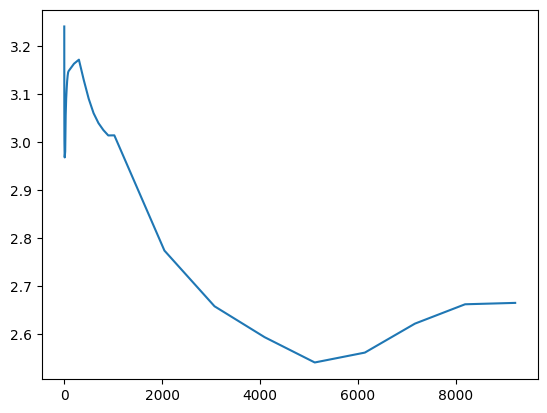

In [2]:
sizes = np.array([1, 2, 3, 4, 5, 6, 7, 
                  8, 9, 10, 20, 30, 40, 50,
                  60, 70, 80, 90, 100, 200, 300,
                  400, 500, 600, 700, 800, 900, 1024,
                  2048, 3072, 4096, 5120, 6144, 7168, 8192,
                  9216]) # In MB
mean_length = np.array([3.2405, 3.0747, 3.0363, 3.0062, 2.9946, 2.9883, 2.9809, 
                        2.9747, 2.9695, 2.9676, 2.9799, 3.0557, 3.0903, 3.1106,
                        3.1269, 3.1377, 3.1449, 3.1476, 3.1490, 3.1629, 3.1713,
                        3.1287, 3.0900, 3.0598, 3.0391, 3.0246, 3.0134, 3.0136,
                        2.7734, 2.6573, 2.5929, 2.5402, 2.5608, 2.6212, 2.6615,
                       2.6644]) # bits / simb

plt.plot(sizes, mean_length)

Fitted exponential model:  f(x) = a·exp(b·x) + c
  a = 0.550581  ±  0.079934
  b = -0.000318  ±  0.000123
  c = 2.542582  ±  0.082862

  R² = 0.810289


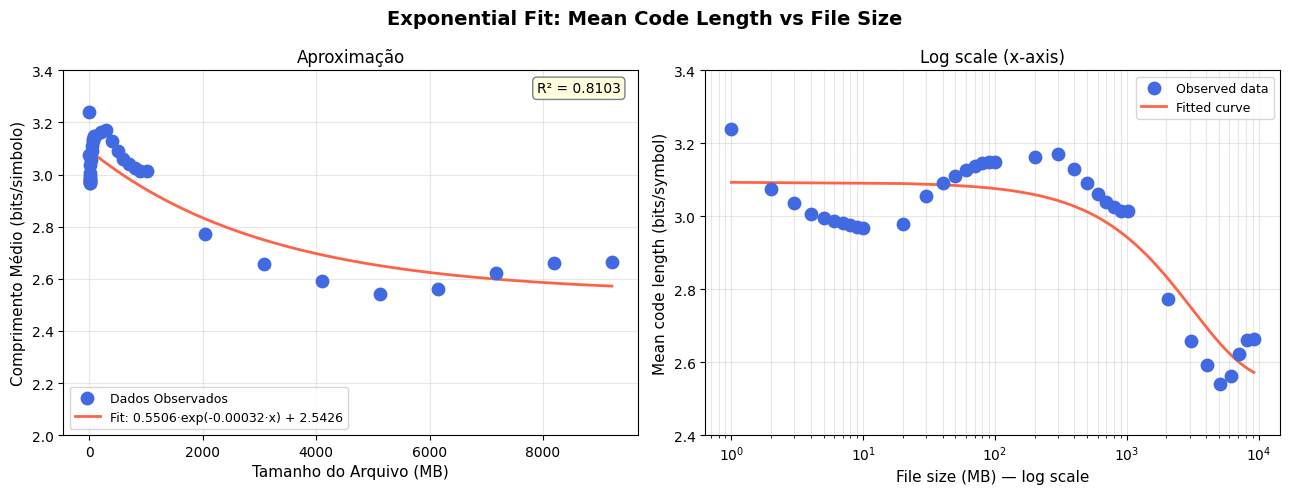

In [3]:
# --- Model: f(x) = a * exp(b * x) + c ---
# The "+ c" term (vertical offset) is crucial here because the data clearly
# approaches a non-zero asymptote rather than decaying to zero.
def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

# Initial parameter guesses: small positive amplitude, slight negative decay, offset ~2.5
p0 = [0.7, -0.001, 2.5]

popt, pcov = curve_fit(exp_model, sizes, mean_length, p0=p0, maxfev=10000)
a, b, c = popt
perr = np.sqrt(np.diag(pcov))  # Standard errors of each parameter

print("=" * 50)
print("Fitted exponential model:  f(x) = a·exp(b·x) + c")
print("=" * 50)
print(f"  a = {a:.6f}  ±  {perr[0]:.6f}")
print(f"  b = {b:.6f}  ±  {perr[1]:.6f}")
print(f"  c = {c:.6f}  ±  {perr[2]:.6f}")
print()

# Goodness of fit
y_pred = exp_model(sizes, *popt)
ss_res = np.sum((mean_length - y_pred) ** 2)
ss_tot = np.sum((mean_length - np.mean(mean_length)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"  R² = {r2:.6f}")
print("=" * 50)

# --- Plot ---
x_smooth = np.linspace(sizes.min(), sizes.max(), 500)
y_smooth = exp_model(x_smooth, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Exponential Fit: Mean Code Length vs File Size", fontsize=14, fontweight="bold")

# --- Linear scale ---
ax = axes[0]
ax.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Dados Observados")
ax.plot(x_smooth, y_smooth, color="tomato", linewidth=2,
        label=f"Fit: {a:.4f}·exp({b:.5f}·x) + {c:.4f}")
ax.set_xlabel("Tamanho do Arquivo (MB)", fontsize=11)
ax.set_ylabel("Comprimento Médio (bits/simbolo)", fontsize=11)
ax.set_title("Aproximação")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(2.0, 3.4)

# Annotate R²
ax.text(0.97, 0.97, f"R² = {r2:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# --- Log scale (x-axis) ---
ax2 = axes[1]
ax2.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Observed data")
ax2.plot(x_smooth, y_smooth, color="tomato", linewidth=2, label="Fitted curve")
ax2.set_xscale("log")
ax2.set_xlabel("File size (MB) — log scale", fontsize=11)
ax2.set_ylabel("Mean code length (bits/symbol)", fontsize=11)
ax2.set_title("Log scale (x-axis)")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_ylim(2.4, 3.4)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/curve_fit.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Plot saved to curve_fit.png")

# Todas Minusculas

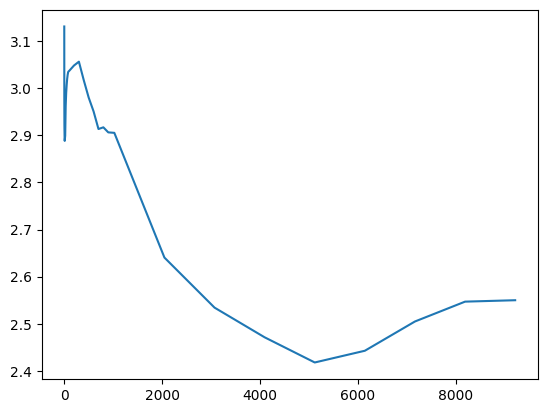

In [4]:
sizes = np.array([1, 2, 3, 4, 5, 6, 7, 
                  8, 9, 10, 20, 30, 40, 50,
                  60, 70, 80, 90, 100, 200, 300,
                  400, 500, 600, 700, 800, 900, 1024,
                  2048, 3072, 4096, 5120, 6144, 7168, 8192,
                  9216]) # In MB
mean_length = np.array([3.1309, 2.9818, 2.9504, 2.9231, 2.9130, 2.9079, 2.9004, 
                        2.8947, 2.8901, 2.8881, 2.8990, 2.9618, 2.9898, 3.0064,
                        3.0196, 3.0281, 3.0340, 3.0357, 3.0365, 3.0481, 3.0562,
                        3.0167, 2.9800, 2.9507, 2.9133, 2.9169, 2.9062, 2.9052,
                        2.6405, 2.5343, 2.4713, 2.4179, 2.4428, 2.5049, 2.5470,
                       2.5500]) # bits / simb

plt.plot(sizes, mean_length)

Fitted exponential model:  f(x) = a·exp(b·x) + c
  a = 0.563490  ±  0.063926
  b = -0.000351  ±  0.000111
  c = 2.433943  ±  0.066015

  R² = 0.851891


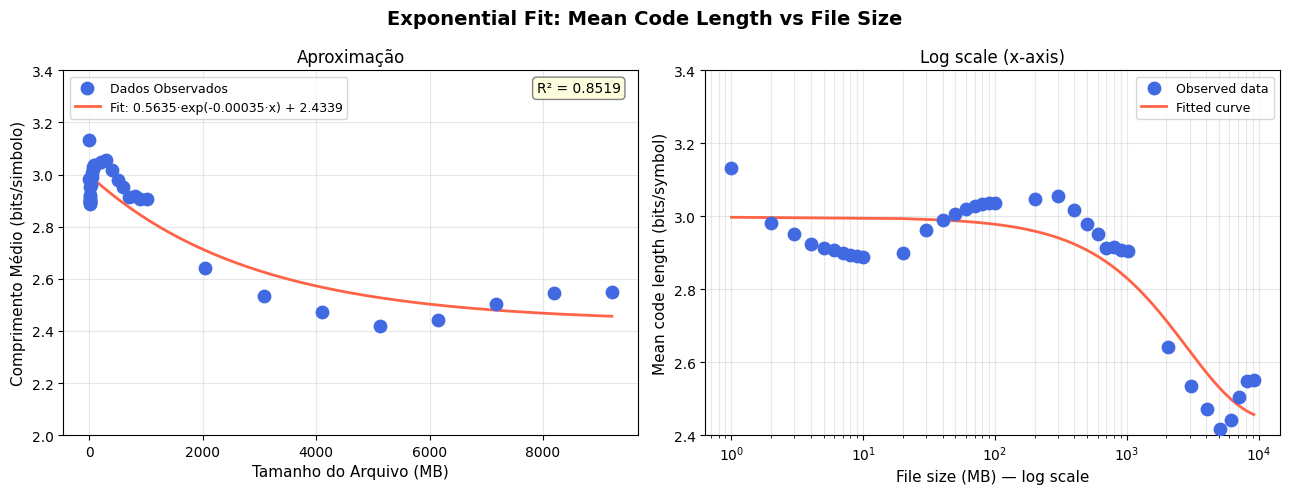

In [5]:
# --- Model: f(x) = a * exp(b * x) + c ---
# The "+ c" term (vertical offset) is crucial here because the data clearly
# approaches a non-zero asymptote rather than decaying to zero.
def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

# Initial parameter guesses: small positive amplitude, slight negative decay, offset ~2.5
p0 = [0.7, -0.001, 2.5]

popt, pcov = curve_fit(exp_model, sizes, mean_length, p0=p0, maxfev=10000)
a, b, c = popt
perr = np.sqrt(np.diag(pcov))  # Standard errors of each parameter

print("=" * 50)
print("Fitted exponential model:  f(x) = a·exp(b·x) + c")
print("=" * 50)
print(f"  a = {a:.6f}  ±  {perr[0]:.6f}")
print(f"  b = {b:.6f}  ±  {perr[1]:.6f}")
print(f"  c = {c:.6f}  ±  {perr[2]:.6f}")
print()

# Goodness of fit
y_pred = exp_model(sizes, *popt)
ss_res = np.sum((mean_length - y_pred) ** 2)
ss_tot = np.sum((mean_length - np.mean(mean_length)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"  R² = {r2:.6f}")
print("=" * 50)

# --- Plot ---
x_smooth = np.linspace(sizes.min(), sizes.max(), 500)
y_smooth = exp_model(x_smooth, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Exponential Fit: Mean Code Length vs File Size", fontsize=14, fontweight="bold")

# --- Linear scale ---
ax = axes[0]
ax.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Dados Observados")
ax.plot(x_smooth, y_smooth, color="tomato", linewidth=2,
        label=f"Fit: {a:.4f}·exp({b:.5f}·x) + {c:.4f}")
ax.set_xlabel("Tamanho do Arquivo (MB)", fontsize=11)
ax.set_ylabel("Comprimento Médio (bits/simbolo)", fontsize=11)
ax.set_title("Aproximação")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(2.0, 3.4)

# Annotate R²
ax.text(0.97, 0.97, f"R² = {r2:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# --- Log scale (x-axis) ---
ax2 = axes[1]
ax2.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Observed data")
ax2.plot(x_smooth, y_smooth, color="tomato", linewidth=2, label="Fitted curve")
ax2.set_xscale("log")
ax2.set_xlabel("File size (MB) — log scale", fontsize=11)
ax2.set_ylabel("Mean code length (bits/symbol)", fontsize=11)
ax2.set_title("Log scale (x-axis)")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_ylim(2.4, 3.4)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/curve_fit.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Plot saved to curve_fit.png")

# Todas as letras com capitalização minúscula e pontuação removida

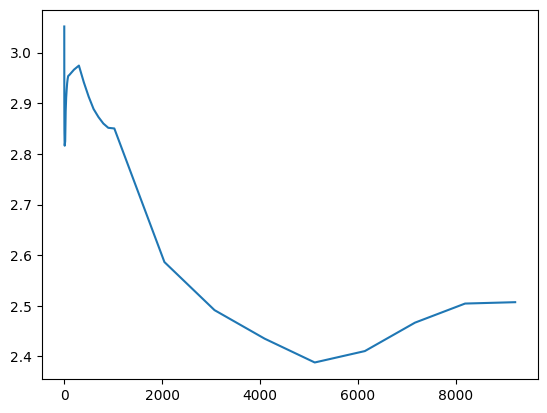

In [6]:
sizes = np.array([1, 2, 3, 4, 5, 6, 7, 
                  8, 9, 10, 20, 30, 40, 50,
                  60, 70, 80, 90, 100, 200, 300,
                  400, 500, 600, 700, 800, 900, 1024,
                  2048, 3072, 4096, 5120, 6144, 7168, 8192,
                  9216]) # In MB
mean_length = np.array([3.0514, 2.9063, 2.8758, 2.8487, 2.8396, 2.8348, 2.8275, 
                        2.8221, 2.8176, 2.8161, 2.8250, 2.8846, 2.9110, 2.9267,
                        2.9395, 2.9476, 2.9532, 2.9546, 2.9551, 2.9662, 2.9742,
                        2.9414, 2.9128, 2.8885, 2.8726, 2.8598, 2.8514, 2.8501,
                        2.5864, 2.4915, 2.4352, 2.3882, 2.4107, 2.4668, 2.5045,
                        2.5072]) # bits / simb

plt.plot(sizes, mean_length)

Fitted exponential model:  f(x) = a·exp(b·x) + c
  a = 0.525631  ±  0.066242
  b = -0.000332  ±  0.000114
  c = 2.394794  ±  0.068575

  R² = 0.838247


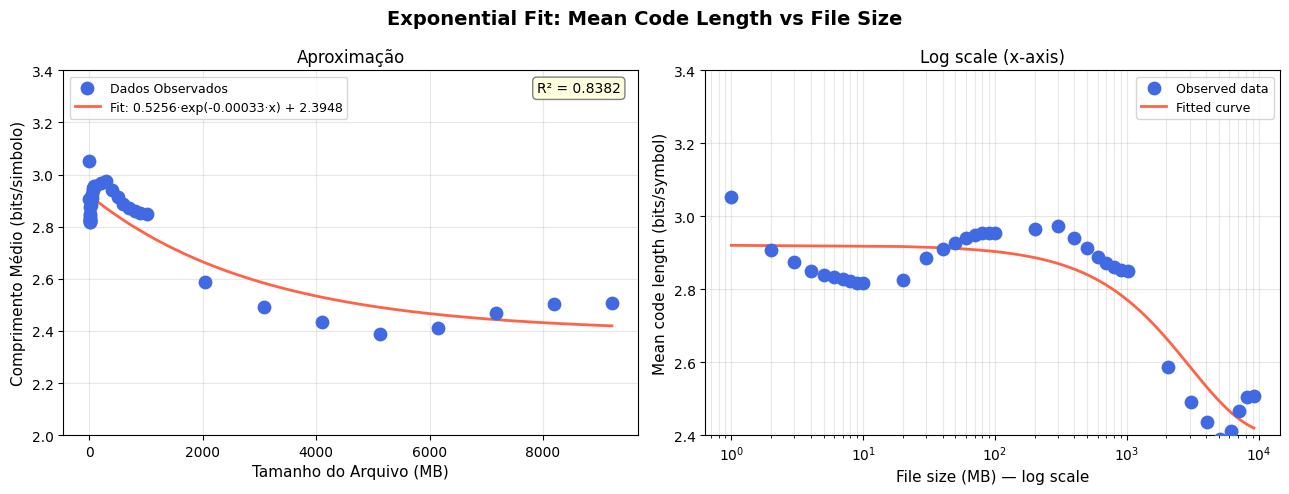

In [7]:
# --- Model: f(x) = a * exp(b * x) + c ---
# The "+ c" term (vertical offset) is crucial here because the data clearly
# approaches a non-zero asymptote rather than decaying to zero.
def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

# Initial parameter guesses: small positive amplitude, slight negative decay, offset ~2.5
p0 = [0.7, -0.001, 2.5]

popt, pcov = curve_fit(exp_model, sizes, mean_length, p0=p0, maxfev=10000)
a, b, c = popt
perr = np.sqrt(np.diag(pcov))  # Standard errors of each parameter

print("=" * 50)
print("Fitted exponential model:  f(x) = a·exp(b·x) + c")
print("=" * 50)
print(f"  a = {a:.6f}  ±  {perr[0]:.6f}")
print(f"  b = {b:.6f}  ±  {perr[1]:.6f}")
print(f"  c = {c:.6f}  ±  {perr[2]:.6f}")
print()

# Goodness of fit
y_pred = exp_model(sizes, *popt)
ss_res = np.sum((mean_length - y_pred) ** 2)
ss_tot = np.sum((mean_length - np.mean(mean_length)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"  R² = {r2:.6f}")
print("=" * 50)

# --- Plot ---
x_smooth = np.linspace(sizes.min(), sizes.max(), 500)
y_smooth = exp_model(x_smooth, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Exponential Fit: Mean Code Length vs File Size", fontsize=14, fontweight="bold")

# --- Linear scale ---
ax = axes[0]
ax.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Dados Observados")
ax.plot(x_smooth, y_smooth, color="tomato", linewidth=2,
        label=f"Fit: {a:.4f}·exp({b:.5f}·x) + {c:.4f}")
ax.set_xlabel("Tamanho do Arquivo (MB)", fontsize=11)
ax.set_ylabel("Comprimento Médio (bits/simbolo)", fontsize=11)
ax.set_title("Aproximação")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(2.0, 3.4)

# Annotate R²
ax.text(0.97, 0.97, f"R² = {r2:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# --- Log scale (x-axis) ---
ax2 = axes[1]
ax2.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Observed data")
ax2.plot(x_smooth, y_smooth, color="tomato", linewidth=2, label="Fitted curve")
ax2.set_xscale("log")
ax2.set_xlabel("File size (MB) — log scale", fontsize=11)
ax2.set_ylabel("Mean code length (bits/symbol)", fontsize=11)
ax2.set_title("Log scale (x-axis)")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_ylim(2.4, 3.4)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/curve_fit.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Plot saved to curve_fit.png")

# Todas as letras com capitalização minúscula, pontuação removida e sem acentos

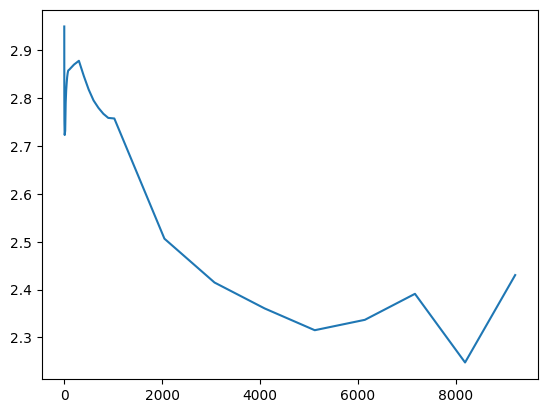

In [8]:
sizes = np.array([1, 2, 3, 4, 5, 6, 7, 
                  8, 9, 10, 20, 30, 40, 50,
                  60, 70, 80, 90, 100, 200, 300,
                  400, 500, 600, 700, 800, 900, 1024,
                  2048, 3072, 4096, 5120, 6144, 7168, 8192,
                  9216]) # In MB
mean_length = np.array([2.9496, 2.8098, 2.7794, 2.7537, 2.7450, 2.7406, 2.7338, 
                        2.7288, 2.7245, 2.7229, 2.7317, 2.7902, 2.8157, 2.8311,
                        2.8437, 2.8516, 2.8571, 2.8585, 2.8591, 2.8700, 2.8779,
                        2.8463, 2.8178, 2.7950, 2.7795, 2.7672, 2.7586, 2.7574,
                        2.5063, 2.4147, 2.3606, 2.3151, 2.3368, 2.3911, 2.2477,
                        2.4303]) # bits / simb

plt.plot(sizes, mean_length)

Fitted exponential model:  f(x) = a·exp(b·x) + c
  a = 0.565784  ±  0.081124
  b = -0.000281  ±  0.000100
  c = 2.258032  ±  0.084201

  R² = 0.852428


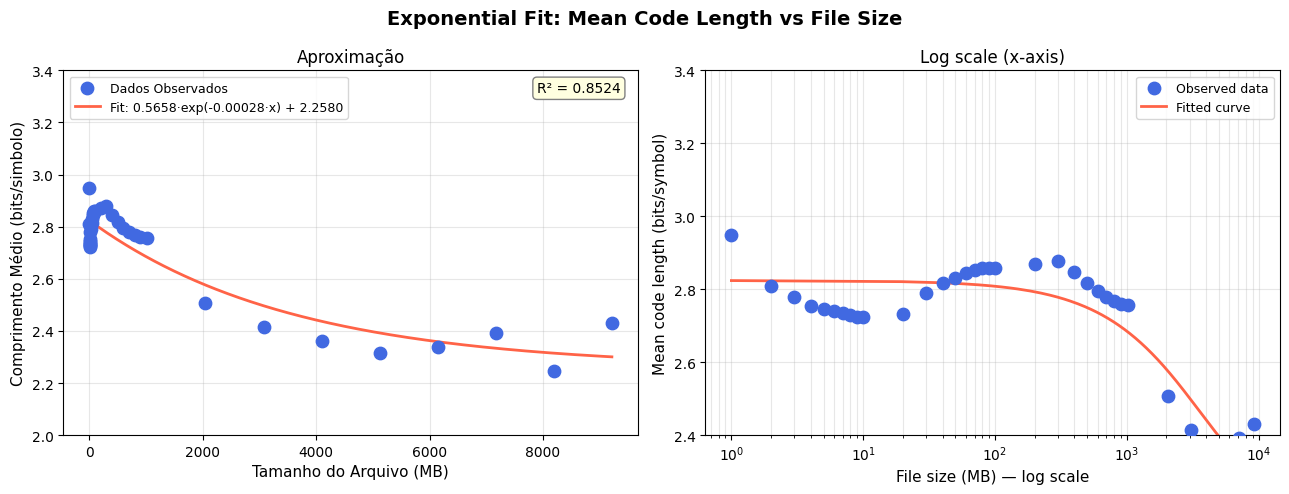

In [9]:
# --- Model: f(x) = a * exp(b * x) + c ---
# The "+ c" term (vertical offset) is crucial here because the data clearly
# approaches a non-zero asymptote rather than decaying to zero.
def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

# Initial parameter guesses: small positive amplitude, slight negative decay, offset ~2.5
p0 = [0.7, -0.001, 2.5]

popt, pcov = curve_fit(exp_model, sizes, mean_length, p0=p0, maxfev=10000)
a, b, c = popt
perr = np.sqrt(np.diag(pcov))  # Standard errors of each parameter

print("=" * 50)
print("Fitted exponential model:  f(x) = a·exp(b·x) + c")
print("=" * 50)
print(f"  a = {a:.6f}  ±  {perr[0]:.6f}")
print(f"  b = {b:.6f}  ±  {perr[1]:.6f}")
print(f"  c = {c:.6f}  ±  {perr[2]:.6f}")
print()

# Goodness of fit
y_pred = exp_model(sizes, *popt)
ss_res = np.sum((mean_length - y_pred) ** 2)
ss_tot = np.sum((mean_length - np.mean(mean_length)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"  R² = {r2:.6f}")
print("=" * 50)

# --- Plot ---
x_smooth = np.linspace(sizes.min(), sizes.max(), 500)
y_smooth = exp_model(x_smooth, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Exponential Fit: Mean Code Length vs File Size", fontsize=14, fontweight="bold")

# --- Linear scale ---
ax = axes[0]
ax.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Dados Observados")
ax.plot(x_smooth, y_smooth, color="tomato", linewidth=2,
        label=f"Fit: {a:.4f}·exp({b:.5f}·x) + {c:.4f}")
ax.set_xlabel("Tamanho do Arquivo (MB)", fontsize=11)
ax.set_ylabel("Comprimento Médio (bits/simbolo)", fontsize=11)
ax.set_title("Aproximação")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(2.0, 3.4)

# Annotate R²
ax.text(0.97, 0.97, f"R² = {r2:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# --- Log scale (x-axis) ---
ax2 = axes[1]
ax2.scatter(sizes, mean_length, color="royalblue", s=80, zorder=5, label="Observed data")
ax2.plot(x_smooth, y_smooth, color="tomato", linewidth=2, label="Fitted curve")
ax2.set_xscale("log")
ax2.set_xlabel("File size (MB) — log scale", fontsize=11)
ax2.set_ylabel("Mean code length (bits/symbol)", fontsize=11)
ax2.set_title("Log scale (x-axis)")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_ylim(2.4, 3.4)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/curve_fit.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Plot saved to curve_fit.png")